# Detective XAI For Tuberculosis
## Use densenet for detect whether TB positive or negative

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

RAW_DIR = os.path.join("..","data_pr", "Raw")
PROCESSED_DIR = os.path.join("..","data_pr", "Processed")

print("Setup complete")
print(f"Raw data directory: {os.listdir(RAW_DIR)}")



Setup complete
Raw data directory: ['ChinaSet_AllFiles', 'TB_Chest_Radiography_Database']


In [2]:
for dataset in os.listdir(RAW_DIR):
    dataset_path = os.path.join(RAW_DIR, dataset)
    if os.path.isdir(dataset_path):
        print(f"\nDataset: {dataset}")
        for sub in os.listdir(dataset_path):
            sub_path = os.path.join(dataset_path, sub)
            if os.path.isdir(sub_path):
                print(f"  Subdirectory: {sub}")
                for file in os.listdir(sub_path):
                    file_path = os.path.join(sub_path, file)
                    if os.path.isfile(file_path):
                        print(f"    File: {file}")


Dataset: ChinaSet_AllFiles
  Subdirectory: ClinicalReadings
    File: CHNCXR_0001_0.txt
    File: CHNCXR_0002_0.txt
    File: CHNCXR_0003_0.txt
    File: CHNCXR_0004_0.txt
    File: CHNCXR_0005_0.txt
    File: CHNCXR_0006_0.txt
    File: CHNCXR_0007_0.txt
    File: CHNCXR_0008_0.txt
    File: CHNCXR_0009_0.txt
    File: CHNCXR_0010_0.txt
    File: CHNCXR_0011_0.txt
    File: CHNCXR_0012_0.txt
    File: CHNCXR_0013_0.txt
    File: CHNCXR_0014_0.txt
    File: CHNCXR_0015_0.txt
    File: CHNCXR_0016_0.txt
    File: CHNCXR_0017_0.txt
    File: CHNCXR_0018_0.txt
    File: CHNCXR_0019_0.txt
    File: CHNCXR_0020_0.txt
    File: CHNCXR_0021_0.txt
    File: CHNCXR_0022_0.txt
    File: CHNCXR_0023_0.txt
    File: CHNCXR_0024_0.txt
    File: CHNCXR_0025_0.txt
    File: CHNCXR_0026_0.txt
    File: CHNCXR_0027_0.txt
    File: CHNCXR_0028_0.txt
    File: CHNCXR_0029_0.txt
    File: CHNCXR_0030_0.txt
    File: CHNCXR_0031_0.txt
    File: CHNCXR_0032_0.txt
    File: CHNCXR_0033_0.txt
    File: CHNCX

In [4]:
# Parse data
ch_img_dir = os.path.join(RAW_DIR,"Chinaset_AllFiles", "CXR_png" )
ch_txt_dir = os.path.join(RAW_DIR,"Chinaset_AllFiles", "ClinicalReadings" )

sample_file = os.listdir(ch_txt_dir)[0]
with open(os.path.join(ch_txt_dir, sample_file)) as f:
    print(f"File name: {sample_file}")
    print(f"Content: \n{f.read()}")

File name: CHNCXR_0001_0.txt
Content: 
male 45yrs
normal


In [16]:
def parse_clinical_text(text):
    text = text.lower()
    age_match = re.search(r"(\d{1,3})\s*y", text)
    age = int(age_match.group(1)) if age_match else None
    if "female" in text:
        sex = "F"
    elif "male" in text:
        sex = "M"
    else:
        sex = None
    return age, sex

records = []
for fname in sorted(os.listdir(ch_txt_dir)):
    if not fname.endswith(".txt"):
        continue
    image_id = fname.split(".")[0]
    label = int(re.search(r"_(\d)\.txt$", fname).group(1))
    
    with open(os.path.join(ch_txt_dir, fname), errors="ignore") as f:
        raw_text = f.read()
    
    age, sex = parse_clinical_text(raw_text)
    
    records.append({
        "image_id": image_id,
        "filepath": os.path.join(ch_img_dir, image_id + ".png"),
        "label": label,
        "age": age,
        "sex": sex
    })

df = pd.DataFrame(records)
df.head(10)


    

,image_id,filepath,label,age,sex
0,CHNCXR_0001_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,45.0,M
1,CHNCXR_0002_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,63.0,M
2,CHNCXR_0003_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,48.0,F
3,CHNCXR_0004_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,58.0,M
4,CHNCXR_0005_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,28.0,M
5,CHNCXR_0006_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,60.0,M
6,CHNCXR_0007_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,53.0,F
7,CHNCXR_0008_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,48.0,M
8,CHNCXR_0009_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,71.0,F
9,CHNCXR_0010_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,59.0,F


In [17]:
df.tail(10)

,image_id,filepath,label,age,sex
652,CHNCXR_0653_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,69.0,M
653,CHNCXR_0654_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,28.0,M
654,CHNCXR_0655_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,33.0,M
655,CHNCXR_0656_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,35.0,F
656,CHNCXR_0657_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,31.0,M
657,CHNCXR_0658_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,41.0,M
658,CHNCXR_0659_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,33.0,M
659,CHNCXR_0660_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,50.0,M
660,CHNCXR_0661_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,26.0,M
661,CHNCXR_0662_1,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,1,32.0,M


Label distribution:
label
1    336
0    326
Name: count, dtype: int64

Missing sex:3/ 662
Missing age:4/ 662


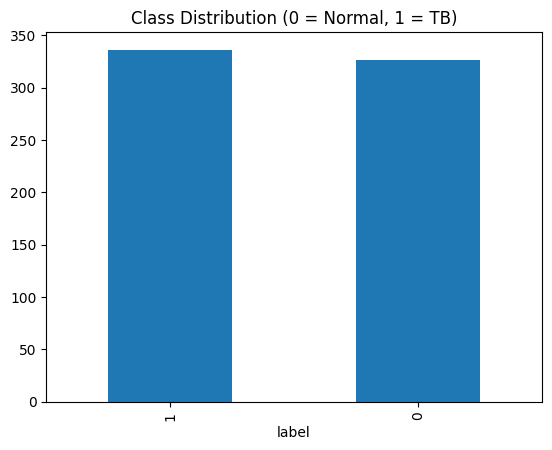

In [18]:
# Santiy check: Class balance & missing data
print("Label distribution:")
print(df['label'].value_counts())
print(f"\nMissing sex:{df['sex'].isna().sum()}/ {len(df)}")
print(f"Missing age:{df['age'].isna().sum()}/ {len(df)}")

df['label'].value_counts().plot(kind='bar', title ='Class Distribution (0 = Normal, 1 = TB)')
plt.show()

In [ ]:
# Inspect x-ray visually
fig, axes = plt.subplots(2,3, figsize = (12,8))

for i, ax in enumerate(axes.flat):
    row = df.iloc[i]
    img = cv2.imread(row['filepath'], cv2.IMREAD_GRAYSCALE) # Read image in grayscale
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {row['label']} | Age: {row['age']} | Sex: {row['sex']}")
    ax.axis('off')
    
plt.tight_layout()
plt.show()
    